# VisioGen — Genetic Eye Disease Modeling & Vision Simulation

This notebook walks through the full VisioGen pipeline interactively:

1. **Part 1 — Genetic Risk Modeling**: Constructing a Polygenic Risk Score (PRS) from GWAS variants, with Gene-Environment (GxE) interaction
2. **Part 2 — Bayesian Markov Progression**: Modeling disease progression as a stochastic process with full uncertainty quantification
3. **Part 3 — Visual Simulation**: Rendering personalized vision trajectories across a lifetime

---

**Disease focus**: Age-related Macular Degeneration (AMD)  
**Why AMD?** It has the richest GWAS data of any eye disease, clean clinical staging, and a visually striking simulation signature (central scotoma). The pipeline generalizes to Glaucoma and other diseases with a single parameter change.

---

## Setup

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

# Make sure the visiogen package is on the path
ROOT = Path().resolve()
for candidate in [ROOT, ROOT.parent, ROOT.parent.parent]:
    if (candidate / 'genetics').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT))
print(f'Project root: {ROOT}')

from genetics.prs_pipeline import PRSModel, EnvironmentalProfile, GxEModel
from progression.bayesian_markov import BayesianMarkovModel
from simulation.disease_filters import EyeDiseaseSimulator

# Plotting defaults
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#0f0f0f',
    'text.color':       'white',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
})

print('All imports successful.')

Project root: C:\Users\14386\OneDrive\Documents\Projects\Genetic-Eye-Disease-Modeling-Vision-Simulation\visiogen
All imports successful.


---

## Part 1 — Polygenic Risk Score (PRS) Modeling

### Background

A **Polygenic Risk Score** aggregates the effects of many genetic variants (SNPs) identified through Genome-Wide Association Studies (GWAS). For each individual, it is computed as:

$$\text{PRS}_i = \sum_{j=1}^{M} \beta_j \cdot g_{ij}$$

where:
- $M$ = number of variants
- $\beta_j$ = effect size (log-odds ratio) of variant $j$ from GWAS
- $g_{ij} \in \{0, 1, 2\}$ = dosage of the risk allele for individual $i$ at variant $j$

We standardize the raw PRS to a z-score using the expected mean and variance under Hardy-Weinberg equilibrium:

$$\mu_{\text{PRS}} = \sum_j 2 p_j \beta_j \qquad \sigma_{\text{PRS}}^2 = \sum_j 2 p_j (1 - p_j) \beta_j^2$$

where $p_j$ is the risk allele frequency at variant $j$.

In [2]:
# Initialize the PRS model for AMD
prs_model = PRSModel(disease='AMD')

print(f'Disease      : {prs_model.disease}')
print(f'Variants     : {prs_model.n_variants}')
print(f'PRS mean     : {prs_model._prs_mean:.4f}  (expected under HWE)')
print(f'PRS std      : {prs_model._prs_std:.4f}')
print()
print('GWAS variants used:')
prs_model.variants[['rsid', 'effect_size', 'risk_allele_freq']].style.format({
    'effect_size': '{:.3f}',
    'risk_allele_freq': '{:.3f}'
})

Disease      : AMD
Variants     : 15
PRS mean     : 2.2986  (expected under HWE)
PRS std      : 0.7765

GWAS variants used:


,rsid,effect_size,risk_allele_freq
0,rs1061170,0.650,0.350
1,rs10490924,0.590,0.220
2,rs2230199,0.210,0.230
3,rs9332739,0.190,0.120
4,rs10737680,0.170,0.550
5,rs3750847,0.550,0.250
6,rs1329428,0.180,0.600
7,rs4698775,0.150,0.380
8,rs13081855,0.120,0.140
9,rs8135665,0.100,0.450


### 1.1 Simulate a synthetic genotype

In the absence of real patient data, we simulate genotypes under Hardy-Weinberg equilibrium:

$$g_{ij} \sim \text{Binomial}(2, p_j)$$

This reflects the probability of inheriting 0, 1, or 2 copies of the risk allele.

In [3]:
# Simulate one individual's genotype
np.random.seed(42)
genotype = prs_model.simulate_genotype(n_individuals=1, seed=42)[0]

print('Simulated genotype (risk allele dosage per variant):')
for rsid, dosage, effect in zip(
    prs_model.variants['rsid'],
    genotype,
    prs_model.variants['effect_size']
):
    bar = '█' * int(dosage * 10)
    print(f'  {rsid:<14}  dosage={dosage}  effect={effect:.3f}  {bar}')

Simulated genotype (risk allele dosage per variant):
  rs1061170       dosage=0  effect=0.650  
  rs10490924      dosage=1  effect=0.590  ██████████
  rs2230199       dosage=1  effect=0.210  ██████████
  rs9332739       dosage=0  effect=0.190  
  rs10737680      dosage=2  effect=0.170  ████████████████████
  rs3750847       dosage=0  effect=0.550  
  rs1329428       dosage=2  effect=0.180  ████████████████████
  rs4698775       dosage=2  effect=0.150  ████████████████████
  rs13081855      dosage=0  effect=0.120  
  rs8135665       dosage=1  effect=0.100  ██████████
  rs3812111       dosage=0  effect=0.140  
  rs429608        dosage=2  effect=0.220  ████████████████████
  rs11200638      dosage=1  effect=0.480  ██████████
  rs2736911       dosage=0  effect=0.110  
  rs1864163       dosage=0  effect=0.090  


### 1.2 Compute the PRS

In [4]:
prs_z = float(prs_model.compute_prs(genotype)[0])
prs_prob = float(prs_model.prs_to_probability(np.array([prs_z]))[0])

print(f'Raw PRS (z-score)  : {prs_z:+.4f}')
print(f'PRS probability    : {prs_prob:.4f}')
print()
if prs_z > 1:
    print('Interpretation: This individual is in the upper tail of genetic risk.')
elif prs_z > 0:
    print('Interpretation: This individual is above average genetic risk.')
else:
    print('Interpretation: This individual is below average genetic risk.')

Raw PRS (z-score)  : +0.6715
PRS probability    : 0.5093

Interpretation: This individual is above average genetic risk.


### 1.3 Gene-Environment (GxE) Interaction

A key limitation of standard PRS is that it treats genetic risk as static and independent of environment. In reality, environmental factors *modulate* genetic risk — a concept called **Gene-Environment interaction (GxE)**.

Our GxE model computes an adjusted log-odds:

$$\log\text{-odds}_{\text{adj}} = \text{PRS} + \boldsymbol{\beta}_{\text{env}} \cdot \mathbf{E} + \boldsymbol{\gamma} \cdot (\text{PRS} \times \mathbf{E})$$

The third term — $\boldsymbol{\gamma} \cdot (\text{PRS} \times \mathbf{E})$ — is the interaction: it captures how the *effect* of genetic risk changes depending on lifestyle.

The final composite risk score is obtained via sigmoid: $r = \sigma(\log\text{-odds}_{\text{adj}})$

In [5]:
# Define an environmental profile
env = EnvironmentalProfile(
    age=50,
    smoking=True,       # smoker — known AMD risk factor
    bmi=26.5,
    uv_exposure=0.55,
    diabetes=False,
    systolic_bp=125.0,
    diet_quality=0.5,
    physical_act=0.4,
)

composite_risk = prs_model.compute_risk(genotype, env)
prs_model.print_summary(genotype, env)


  AMD — Individual Risk Summary
  Raw PRS (z-score)    : +0.671
  PRS probability      : 0.509
  Composite risk (GxE) : 0.655

  Environmental inputs:
    age                 : 50
    smoking             : True
    bmi                 : 26.5
    uv_exposure         : 0.55
    diabetes            : False
    systolic_bp         : 125.0
    diet_quality        : 0.5
    physical_act        : 0.4



### 1.4 Population Risk Distribution

How does this individual's risk compare to the general population? We simulate 2,000 individuals and plot the distribution.

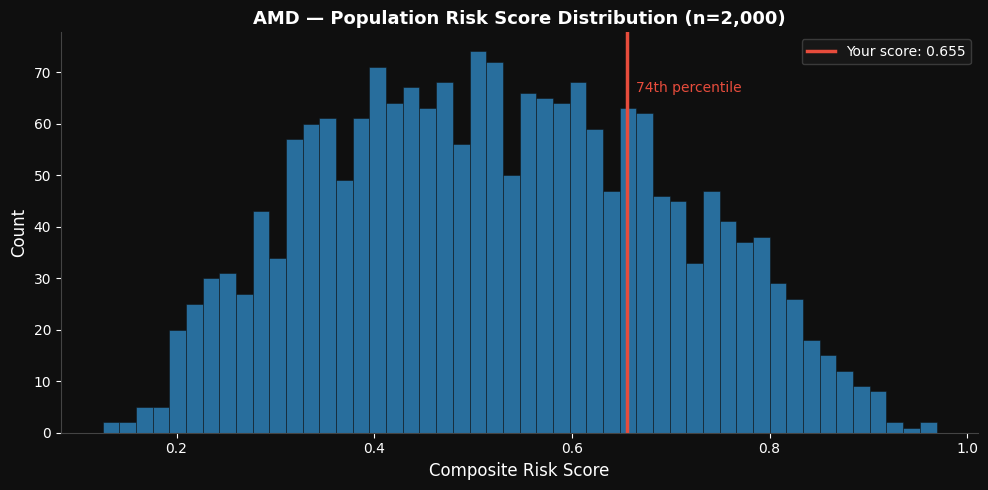

In [6]:
prs_model.plot_population_distribution(
    n=2000,
    env_profile=env,
    highlight_score=composite_risk,
)

### 1.5 GxE Sensitivity Analysis

How much does smoking change the risk for this individual? The interaction term means the answer depends on their genetic background.

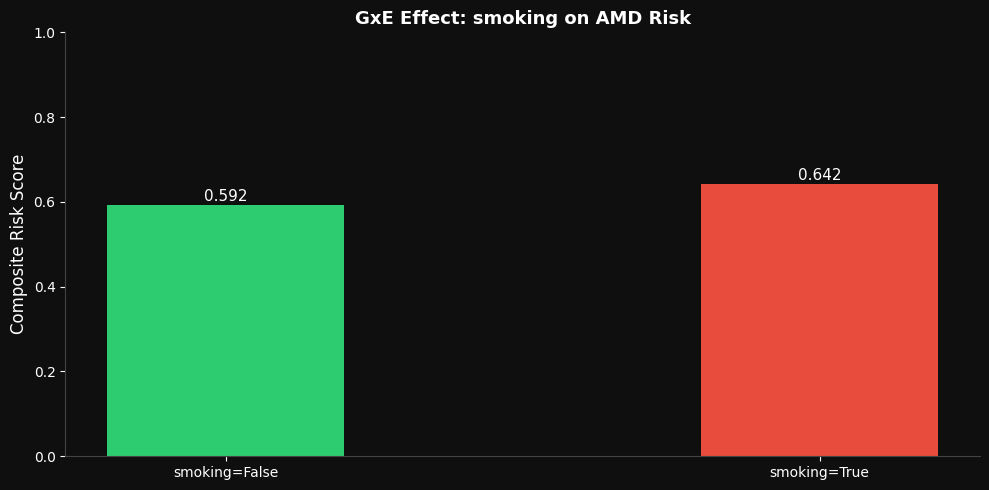

In [7]:
# Smoking — binary GxE effect
prs_model.plot_gxe_sensitivity(genotype, env_variable='smoking')

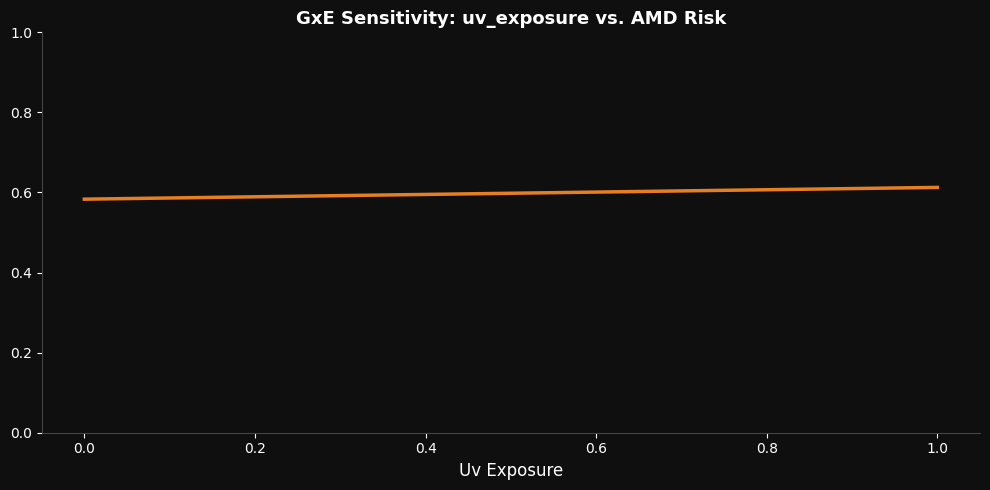

In [8]:
# UV exposure — continuous GxE effect
prs_model.plot_gxe_sensitivity(genotype, env_variable='uv_exposure')

---

## Part 2 — Bayesian Markov Progression Model

### Background

We model disease progression as a **discrete-time Markov chain** over ordered severity stages:

$$\text{Healthy} \rightarrow \text{Early AMD} \rightarrow \text{Intermediate AMD} \rightarrow \text{Advanced AMD} \rightarrow \text{Legal Blindness}$$

At each time step (1 year), a patient in stage $s$ transitions to stage $s+1$ with probability $p_s$, or remains with probability $1 - p_s$.

**Key innovation**: rather than treating $p_s$ as a fixed number, we model it as a **Beta-distributed random variable**:

$$p_s \sim \text{Beta}(\alpha_s, \beta_s)$$

The Beta distribution is the natural prior for a probability — it is supported on $[0,1]$ and has interpretable parameters: $\alpha/(\alpha+\beta)$ is the prior mean, and larger $\alpha+\beta$ means more certainty.

**Genetic risk modulation**: the genetic risk score $r$ amplifies transition probabilities multiplicatively:

$$p_s^{(r)} = \min\left(p_s \cdot (1 + A \cdot r),\ 1\right)$$

where $A$ is the maximum amplification factor (disease-specific).

**Uncertainty propagation**: we propagate uncertainty via **Monte Carlo** — sampling transition probabilities from their Beta priors across thousands of simulated chains, then computing posterior statistics.

In [9]:
# Inspect the transition priors
markov = BayesianMarkovModel(disease='AMD')

print('Transition priors (Beta distributions):')
print(f'  {"Transition":<40} {"Prior":<35} {"Mean":>8} {"Std":>8}')
print('  ' + '-'*95)
stages = markov.stages
for i, prior in enumerate(markov.priors):
    transition = f'{stages[i]} → {stages[i+1]}'
    print(f'  {transition:<40} {str(prior):<35} {prior.mean:>8.4f} {prior.std:>8.4f}')

Transition priors (Beta distributions):
  Transition                               Prior                                   Mean      Std
  -----------------------------------------------------------------------------------------------
  Healthy → Early AMD                      Beta(α=1.5, β=18.5) | mean=0.075, std=0.057   0.0750   0.0575
  Early AMD → Intermediate AMD             Beta(α=2.0, β=18.0) | mean=0.100, std=0.065   0.1000   0.0655
  Intermediate AMD → Advanced AMD          Beta(α=3.0, β=17.0) | mean=0.150, std=0.078   0.1500   0.0779
  Advanced AMD → Legal Blindness           Beta(α=2.5, β=17.5) | mean=0.125, std=0.072   0.1250   0.0722


### 2.1 Simulate a progression trajectory

In [10]:
# Use the composite risk score from Part 1
trajectory = markov.simulate_trajectory(
    risk_score=composite_risk,
    age_start=40,
    age_end=80,
    n_simulations=5000,
    seed=42,
)

markov.print_summary(trajectory)


  AMD Progression Summary
  Risk Score : 0.655
  Age Range  : 40 – 80
  Simulations: 5,000
  Stage                     P(at age 60) P(at age 75)
  --------------------------------------------------
  Healthy                         12.5%        6.4%
  Early AMD                       11.3%        5.1%
  Intermediate AMD                 7.6%        2.7%
  Advanced AMD                    13.4%        5.1%
  Legal Blindness                 55.3%       80.7%

  Expected age at 'Advanced AMD':
    Mean   : 54.5 yrs
    Median : 52.0 yrs
    Std    : 8.8 yrs
    Never reached (in window): 11.7%



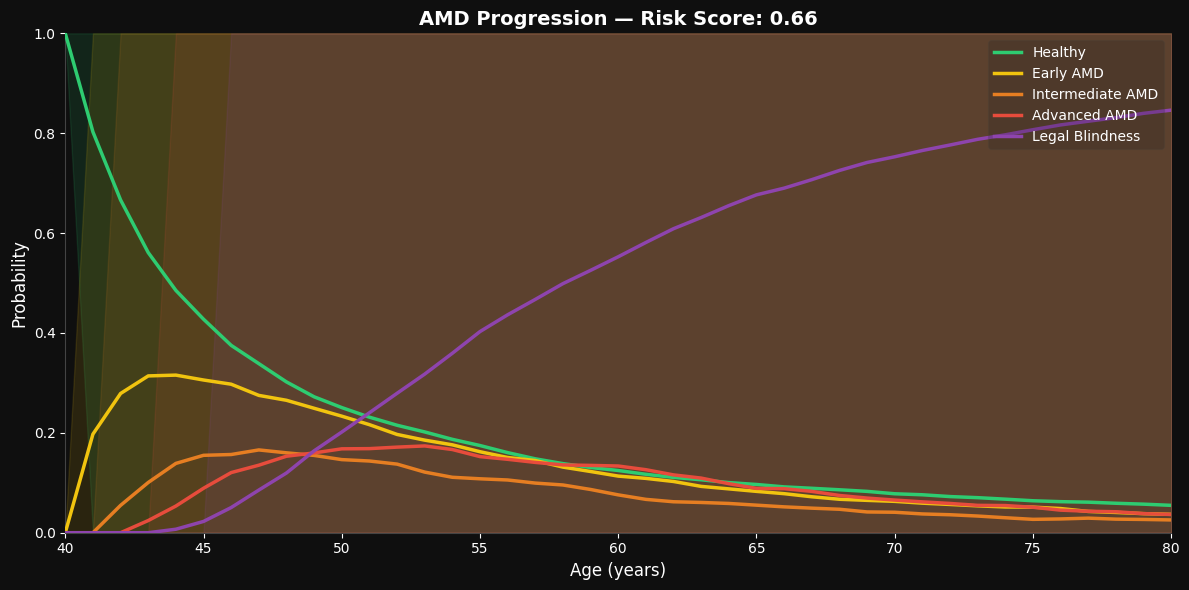

In [11]:
# Plot the full trajectory with confidence intervals
markov.plot_trajectory(trajectory, show_ci=True)

### 2.2 The role of uncertainty

The shaded bands above represent the 95% credible interval across Monte Carlo simulations. This is not just aesthetic — it reflects genuine scientific uncertainty in the transition probabilities.

Let's compare what the trajectory looks like *with* vs. *without* uncertainty quantification.

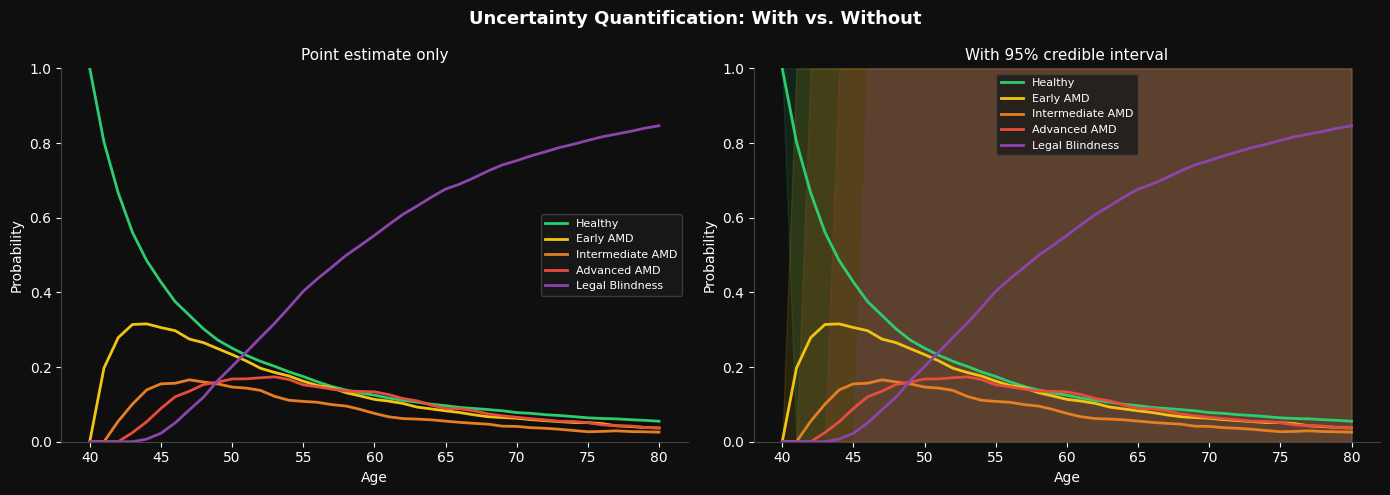

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Uncertainty Quantification: With vs. Without', color='white', fontsize=13, fontweight='bold')

for ax, show_ci, title in zip(axes, [False, True], ['Point estimate only', 'With 95% credible interval']):
    ages = trajectory.ages
    for i, (stage, color) in enumerate(zip(trajectory.stage_names, trajectory.stage_colors)):
        ax.plot(ages, trajectory.stage_probs[:, i], color=color, linewidth=2, label=stage)
        if show_ci:
            ax.fill_between(
                ages,
                trajectory.stage_probs_ci['lower'][:, i],
                trajectory.stage_probs_ci['upper'][:, i],
                color=color, alpha=0.12
            )
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('Age', color='white')
    ax.set_ylabel('Probability', color='white')
    ax.set_ylim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#444')
    ax.spines['left'].set_color('#444')
    ax.legend(fontsize=8, labelcolor='white', facecolor='#1a1a1a', edgecolor='#444')

plt.tight_layout()
plt.show()

### 2.3 How much does genetic risk matter?

Compare progression curves across a range of PRS values — from low (0.1) to high (0.9).

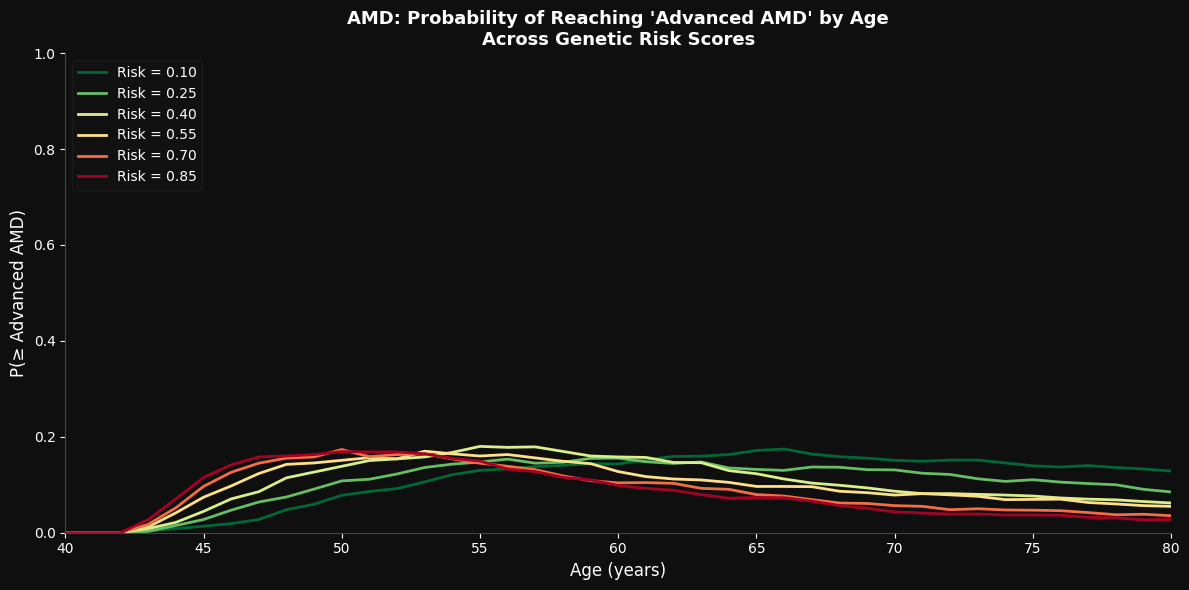

In [13]:
markov.plot_risk_comparison(
    risk_scores=[0.1, 0.25, 0.4, 0.55, 0.7, 0.85],
    target_stage=3,  # Advanced AMD
    age_start=40,
    age_end=80,
    n_simulations=2000,
)

### 2.4 Expected age of reaching advanced disease

In [14]:
print('Expected age of reaching Advanced AMD, by risk score:\n')
print(f'  {"Risk Score":<15} {"Mean Age":>10} {"Median Age":>12} {"Std":>8} {"Never (%)">10}')
print('  ' + '-'*60)

for rs in [0.10, 0.25, 0.40, 0.55, 0.70, 0.85]:
    result = markov.expected_time_to_stage(
        risk_score=rs, target_stage=3,
        age_start=40, age_end=90, n_simulations=3000
    )
    if result['mean'] is not None:
        print(f'  {rs:<15.2f} {result["mean"]:>10.1f} {result["median"]:>12.1f} '
              f'{result["std"]:>8.1f} {result["never_reached_pct"]:>10.1f}')
    else:
        print(f'  {rs:<15.2f} {"N/A":>10} {"N/A":>12} {"N/A":>8} {100.0:>10.1f}')

Expected age of reaching Advanced AMD, by risk score:



TypeError: '>' not supported between instances of 'str' and 'int'

---

## Part 3 — Visual Simulation

### Background

Each disease stage maps to a parameterized image transformation. The **severity score** — derived from the expected disease stage at a given age — drives the intensity of the transformation.

We derive a continuous severity score from the stage probability distribution:

$$\text{severity}(t) = \frac{\mathbb{E}[\text{stage}(t)]}{N_{\text{stages}} - 1} = \frac{\sum_s s \cdot P(\text{stage} = s \mid t)}{N_{\text{stages}} - 1}$$

This links the probabilistic model output directly to the visual simulation.

In [ ]:
# Derive severity scores from trajectory
def stage_probs_to_severity(stage_probs):
    n_stages = stage_probs.shape[1]
    stage_indices = np.arange(n_stages)
    expected_stage = stage_probs @ stage_indices
    return expected_stage / (n_stages - 1)

severity_scores = stage_probs_to_severity(trajectory.stage_probs)

# Plot severity over age
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trajectory.ages, severity_scores, color='#e67e22', linewidth=2.5)
ax.fill_between(trajectory.ages, severity_scores, alpha=0.15, color='#e67e22')
ax.set_xlabel('Age', color='white')
ax.set_ylabel('Severity Score', color='white')
ax.set_title(f'AMD Severity Trajectory (Risk Score = {composite_risk:.3f})', color='white', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('#444')
ax.spines['left'].set_color('#444')

# Mark selected ages
for age in [50, 60, 70, 80]:
    idx = age - 40
    ax.axvline(age, color='white', alpha=0.2, linestyle='--', linewidth=1)
    ax.annotate(f'{severity_scores[idx]:.2f}', xy=(age, severity_scores[idx]),
                xytext=(age + 0.5, severity_scores[idx] + 0.03),
                color='white', fontsize=9)

plt.tight_layout()
plt.show()

### 3.1 Load a sample image

In [ ]:
sim = EyeDiseaseSimulator()
image = sim.load_sample_image(size=(500, 750))

fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(image)
ax.set_title('Sample Scene — Normal Vision', color='white', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

print('To use your own image, replace the line above with:')
print("  image = sim._load('path/to/your/image.jpg')")

### 3.2 Personalized vision trajectory

This is the core output of the project: what does this individual see at each decade of life, given their genetic risk profile?

In [ ]:
sim.show_trajectory_frames(
    image=image,
    disease='AMD',
    ages=trajectory.ages,
    severity_scores=severity_scores,
    selected_ages=[40, 50, 60, 70, 80],
)

### 3.3 Disease progression strip — AMD

In [ ]:
sim.show_progression(image, disease='AMD', n_steps=5)

### 3.4 All diseases at moderate severity

Each disease has a distinct and recognizable visual signature.

In [ ]:
sim.show_all_diseases(image, severity=0.6)

### 3.5 Low risk vs. high risk — vision at age 70

In [ ]:
low_risk_score  = 0.15
high_risk_score = 0.80

traj_low  = markov.simulate_trajectory(low_risk_score,  40, 80, 3000, seed=42)
traj_high = markov.simulate_trajectory(high_risk_score, 40, 80, 3000, seed=42)

sev_low  = stage_probs_to_severity(traj_low.stage_probs)
sev_high = stage_probs_to_severity(traj_high.stage_probs)

age_70_idx = 70 - 40

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle('Vision at Age 70: Low vs. High Genetic Risk', color='white', fontsize=13, fontweight='bold')

panels = [
    (image,                                                            'Normal Vision'),
    (sim.simulate(image, 'AMD', float(sev_low[age_70_idx])),           f'Low Risk (sev={sev_low[age_70_idx]:.2f})'),
    (sim.simulate(image, 'AMD', float(sev_high[age_70_idx])),          f'High Risk (sev={sev_high[age_70_idx]:.2f})'),
]

for ax, (img, title) in zip(axes, panels):
    ax.imshow(img)
    ax.set_title(title, color='white', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

---

## Summary

This notebook demonstrated the full VisioGen pipeline:

| Step | Method | Output |
|---|---|---|
| Genetic risk | PRS + GxE model | Composite risk score $r \in [0,1]$ |
| Progression | Bayesian Markov chain | Stage probability distribution over age |
| Visual simulation | Parameterized image transforms | Vision frames at each age |

**What makes this approach novel:**
- Uncertainty is propagated end-to-end — from Beta priors on transitions to confidence bands on visual output
- GxE interaction means environmental factors don't just add to genetic risk — they modulate it
- The pipeline is disease-agnostic: change `disease='AMD'` to `disease='Glaucoma'` to run the same analysis for glaucoma

---

## Next Steps

- [ ] Ancestry portability analysis: quantify PRS accuracy degradation across ancestries
- [ ] Coupled disease model: correlated Markov chains for AMD + diabetic retinopathy
- [ ] Gaze-contingent simulation: scotomas that follow a simulated fixation point
- [ ] Uncertainty-aware rendering: visual ensemble showing the cone of possible visual outcomes
- [ ] iOS app integration